# Experimental RCMC maps: C1-C4 allelic series

Prepare the RCMC midbrain WT and mutant `.mcool` files at 2,048 bp resolution, process the observed Hi-C maps, compare the C1-C4^flx and C1-C4^flx;Cre alleles, and save the cross-boundary difference block used to define the optimization target.

The central TAD is cropped to **bins 165–323** of the processed 512-bin output. All generated data files are saved under `data/` and all figures under `plots/`.

In [1]:
import os
import re
import copy

import cooler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.convolution import Gaussian2DKernel, convolve
from cooltools.lib.numutils import (
    adaptive_coarsegrain,
    interp_nan,
    observed_over_expected,
    set_diag,
)

# -----------------------------------------------------------------------------
# Paths and constants
# -----------------------------------------------------------------------------
DATA_DIR = "data"
PLOTS_DIR = "plots"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

PATHS = {
    "flx": "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/validation/GSE271759_RCMC_midbrain_WT_merged.mcool",
    "cre": "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/validation/GSE271759_RCMC_midbrain_MT_merged.mcool",
}

CHROM = "chr7"
BASE_RES = 100
BIN_SIZE = 2048
DIAG_OFFSET = 2
PADDING = 64

DEL_START = 144_775_729
LEFT = 144_105_472
SEQ_LEN = 1_310_720
REGION = f"{CHROM}:{LEFT}-{LEFT + SEQ_LEN}"

B_CASSETTE = (DEL_START - LEFT) // BIN_SIZE - PADDING
TAD_LO, TAD_HI = 165, 323

GRAY = "#d3d1c7"
print(f"region: {REGION}")
print(f"cassette bin: {B_CASSETTE}")

region: chr7:144105472-145416192
cassette bin: 263


## Inspect the source multi-resolution coolers

In [2]:
for name, path in PATHS.items():
    print(f"-- {name}: {path}")
    resolutions = cooler.fileops.list_coolers(path)
    print(f"   resolutions: {resolutions}")

    # Use the coarsest available resolution only for metadata inspection.
    c = cooler.Cooler(f"{path}::{resolutions[-1]}")
    print(f"   chroms: {dict(c.chromsizes)}")
    print(f"   balanced: {'weight' in c.bins().columns}")
    print(f"   total contacts: {c.info.get('sum', 'n/a')}")

-- flx: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/validation/GSE271759_RCMC_midbrain_WT_merged.mcool
   resolutions: ['/resolutions/100', '/resolutions/200', '/resolutions/400', '/resolutions/1000', '/resolutions/2000', '/resolutions/5000', '/resolutions/20000', '/resolutions/1000000']
   chroms: {'chr1': 195471971, 'chr2': 182113224, 'chr3': 160039680, 'chr4': 156508116, 'chr5': 151834684, 'chr6': 149736546, 'chr7': 145418243, 'chr8': 129401213, 'chr9': 124595110, 'chr10': 130694993, 'chr11': 122082543, 'chr12': 120129022, 'chr13': 120421639, 'chr14': 124902244, 'chr15': 104043685, 'chr16': 98207768, 'chr17': 94987271, 'chr18': 90702639, 'chr19': 61431566, 'chrM': 16299, 'chrX': 171031299, 'chrY': 91744698}
   balanced: True
   total contacts: 5155434
-- cre: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/validation/GSE271759_RCMC_midbrain_MT_merged.mcool
   resolutions: ['/resolutions/100', '/resolutions/2

## Rebin the experimental maps to 2,048 bp

In [3]:
def rebin_to_2048(path, out_path, chrom=CHROM, bin_size=BIN_SIZE, base=BASE_RES):
    if os.path.exists(out_path):
        print(f"already exists: {out_path}")
        return out_path

    c = cooler.Cooler(f"{path}::/resolutions/{base}")
    bins = cooler.binnify(c.chromsizes[[chrom]], bin_size)

    pix = c.matrix(balance=False, as_pixels=True, join=True).fetch(chrom)
    print(f"  {len(pix):,} pixels at {base} bp")

    b1 = ((pix.start1.values + pix.end1.values) // 2) // bin_size
    b2 = ((pix.start2.values + pix.end2.values) // 2) // bin_size

    df = pd.DataFrame({
        "bin1_id": np.minimum(b1, b2),
        "bin2_id": np.maximum(b1, b2),
        "count": pix["count"].values,
    })
    df = (
        df.groupby(["bin1_id", "bin2_id"], as_index=False)["count"]
        .sum()
        .sort_values(["bin1_id", "bin2_id"])
    )
    print(f"  -> {len(df):,} pixels at {bin_size} bp")

    cooler.create_cooler(out_path, bins, df, ordered=True)
    cooler.balance_cooler(cooler.Cooler(out_path), cis_only=True, store=True)
    return out_path


cool_2048 = {
    name: rebin_to_2048(path, os.path.join(DATA_DIR, f"{name}_chr7_2048.cool"))
    for name, path in PATHS.items()
}

already exists: data/flx_chr7_2048.cool
already exists: data/cre_chr7_2048.cool


## Process the observed Hi-C matrices

In [4]:
def extract_coordinates_from_mseq(mseq_str):
    match = re.match(r"(?P<chrom>\w+):(?P<start>\d+)-(?P<end>\d+)", mseq_str)
    if not match:
        raise ValueError(f"Invalid coordinate format: {mseq_str}")
    return match.group("chrom"), int(match.group("start")), int(match.group("end"))


def process_hic_matrix(
    genome_hic_cool,
    mseq_str,
    diagonal_offset=DIAG_OFFSET,
    padding=PADDING,
    kernel_stddev=1,
    bin_size=BIN_SIZE,
    gaps_df=None,
):
    seq_hic_raw = genome_hic_cool.matrix(balance=True).fetch(mseq_str)
    chrom, start, end = extract_coordinates_from_mseq(mseq_str)

    seq_hic_nan = np.isnan(seq_hic_raw)
    row_nan_mask = np.all(seq_hic_nan, axis=1)
    col_nan_mask = np.all(seq_hic_nan, axis=0)
    seq_hic_raw[row_nan_mask, :] = np.nan
    seq_hic_raw[:, col_nan_mask] = np.nan

    if gaps_df is not None:
        gaps_chr = gaps_df[gaps_df["chr"] == chrom]
        for _, gap in gaps_chr.iterrows():
            if (gap["start"] < end) and (gap["end"] > start):
                gap_start_idx = max(gap["start"] - start, 0) // bin_size
                gap_end_idx = min(gap["end"] - start, seq_hic_raw.shape[0]) // bin_size
                row_nan_mask[gap_start_idx:gap_end_idx] = True
                col_nan_mask[gap_start_idx:gap_end_idx] = True
        seq_hic_raw[row_nan_mask, :] = np.nan
        seq_hic_raw[:, col_nan_mask] = np.nan

    clipval = np.nanmedian(np.diag(seq_hic_raw, diagonal_offset))
    for i in range(-diagonal_offset + 1, diagonal_offset):
        set_diag(seq_hic_raw, clipval, i)
    seq_hic_raw = np.clip(seq_hic_raw, 0, clipval)
    seq_hic_raw[seq_hic_nan] = np.nan

    seq_hic_smoothed = adaptive_coarsegrain(
        seq_hic_raw,
        genome_hic_cool.matrix(balance=False).fetch(mseq_str),
        cutoff=2,
        max_levels=8,
    )
    seq_hic_nan = np.isnan(seq_hic_smoothed)
    seq_hic_obsexp = observed_over_expected(seq_hic_smoothed, ~seq_hic_nan)[0]
    log_hic_obsexp = np.log(seq_hic_obsexp)

    if padding > 0:
        log_hic_obsexp = log_hic_obsexp[padding:-padding, padding:-padding]

    log_hic_obsexp = interp_nan(log_hic_obsexp)
    for i in range(-diagonal_offset + 1, diagonal_offset):
        set_diag(log_hic_obsexp, 0, i)

    return convolve(log_hic_obsexp, Gaussian2DKernel(x_stddev=kernel_stddev))

In [5]:
def coverage_mask(cool, region, padding=PADDING, rel_thresh=0.1):
    # True where the bin has real raw coverage, before interpolation.
    cov = np.nansum(cool.matrix(balance=False).fetch(region), axis=1)
    positive = cov[cov > 0]
    threshold = np.nanmedian(positive) * rel_thresh if positive.size else 0
    return (cov > threshold)[padding:-padding]


obs, cov_mask = {}, {}
for name, path in cool_2048.items():
    c = cooler.Cooler(path)
    obs[name] = process_hic_matrix(c, REGION)
    cov_mask[name] = coverage_mask(c, REGION)
    print(
        f"{name}: {obs[name].shape}, {cov_mask[name].mean():.1%} of bins covered, "
        f"cassette bin covered = {cov_mask[name][B_CASSETTE]}"
    )

# Bins usable in both alleles. Mask the cassette and immediate neighbours,
# since the Cre allele has no DNA at this location.
valid = cov_mask["flx"] & cov_mask["cre"]
valid[B_CASSETTE - 1 : B_CASSETTE + 2] = False
print(f"bins with data in both alleles: {valid.sum()} / {len(valid)}")


def apply_valid_mask(mat, valid_mask):
    out = mat.copy().astype(float)
    out[~valid_mask, :] = np.nan
    out[:, ~valid_mask] = np.nan
    return out


obs_m = {name: apply_valid_mask(mat, valid) for name, mat in obs.items()}
diff = apply_valid_mask(obs["cre"] - obs["flx"], valid)

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


flx: (512, 512), 70.5% of bins covered, cassette bin covered = True
cre: (512, 512), 70.5% of bins covered, cassette bin covered = True
bins with data in both alleles: 358 / 512


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


## Full-window experimental maps

VDIFF = 0.582


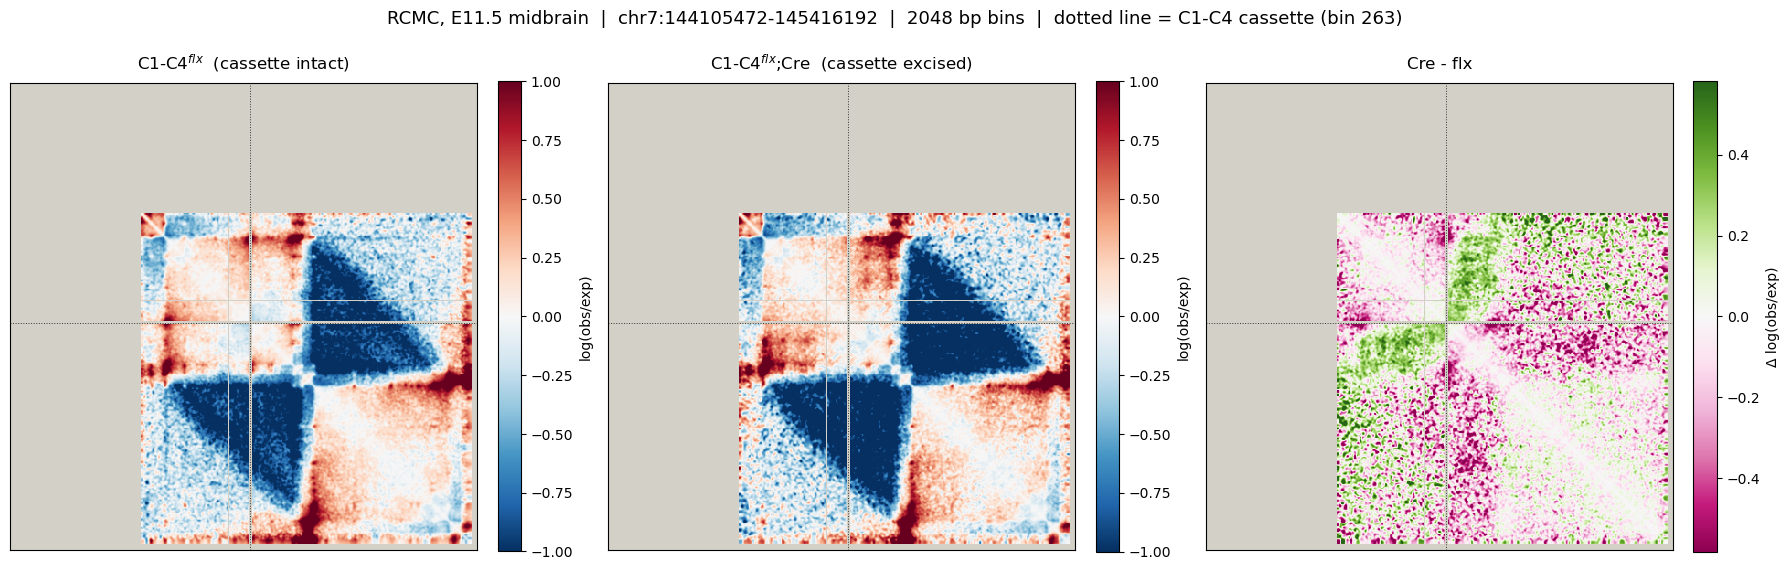

In [6]:
cmap_abs = copy.copy(plt.get_cmap("RdBu_r"))
cmap_abs.set_bad(GRAY)
cmap_diff = copy.copy(plt.get_cmap("PiYG"))
cmap_diff.set_bad(GRAY)

VABS = 1.0
VDIFF = float(np.nanpercentile(np.abs(diff), 98))
print(f"VDIFF = {VDIFF:.3f}")

panels = [
    (obs_m["flx"], "C1-C4$^{flx}$  (cassette intact)", cmap_abs, VABS, "log(obs/exp)"),
    (obs_m["cre"], "C1-C4$^{flx}$;Cre  (cassette excised)", cmap_abs, VABS, "log(obs/exp)"),
    (diff, "Cre - flx", cmap_diff, VDIFF, "Δ log(obs/exp)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
for ax, (mat, title, cmap, v, cbar_label) in zip(axes, panels):
    im = ax.imshow(mat, cmap=cmap, vmin=-v, vmax=v, interpolation="none")
    ax.axvline(B_CASSETTE, color="k", lw=0.7, ls=":", alpha=0.75)
    ax.axhline(B_CASSETTE, color="k", lw=0.7, ls=":", alpha=0.75)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

fig.suptitle(
    f"RCMC, E11.5 midbrain  |  {REGION}  |  2048 bp bins  "
    f"|  dotted line = C1-C4 cassette (bin {B_CASSETTE})",
    fontsize=13,
    y=1.00,
)
plt.tight_layout()
# fig.savefig(os.path.join(PLOTS_DIR, "observed_flx_vs_cre.png"), dpi=300, bbox_inches="tight")
plt.show()

## Central TAD: bins 165-323

In [7]:
sl = slice(TAD_LO, TAD_HI + 1)
B_REL = B_CASSETTE - TAD_LO

TAD_GENOMIC_START = LEFT + (TAD_LO + PADDING) * BIN_SIZE
TAD_GENOMIC_END = LEFT + (TAD_HI + 1 + PADDING) * BIN_SIZE

crop = {
    "flx": obs_m["flx"][sl, sl],
    "cre": obs_m["cre"][sl, sl],
    "diff": diff[sl, sl],
}

VDIFF_TAD = float(np.nanpercentile(np.abs(crop["diff"]), 98))
n = crop["flx"].shape[0]

print(f"TAD bins: {TAD_LO}-{TAD_HI} ({n} bins, {n * BIN_SIZE / 1000:.0f} kb)")
print(f"TAD genomic region: {CHROM}:{TAD_GENOMIC_START:,}-{TAD_GENOMIC_END:,}")
print(f"cassette: bin {B_CASSETTE} (cropped bin {B_REL})")
print(f"VDIFF: {VDIFF_TAD:.3f}")

TAD bins: 165-323 (159 bins, 326 kb)
TAD genomic region: chr7:144,574,464-144,900,096
cassette: bin 263 (cropped bin 98)
VDIFF: 0.498


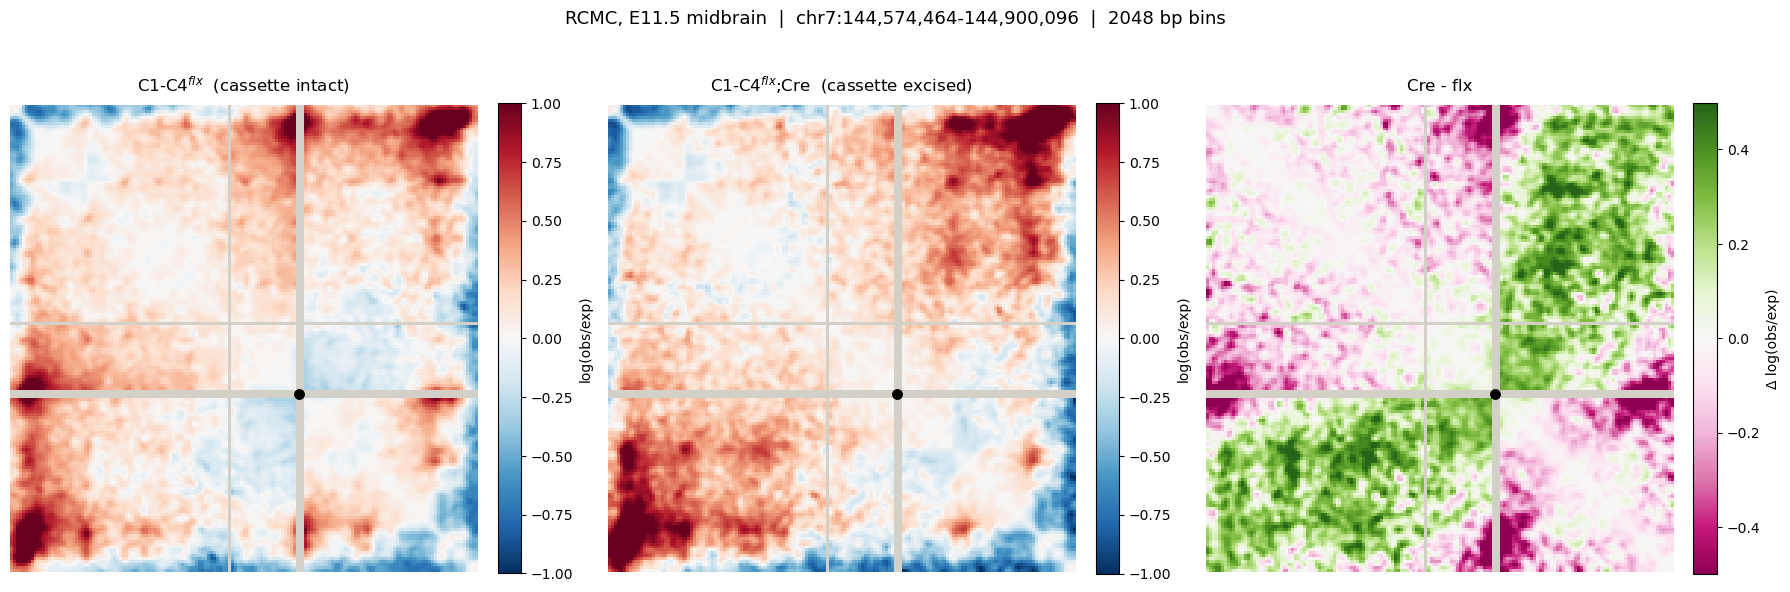

In [8]:
panels = [
    (crop["flx"], "C1-C4$^{flx}$  (cassette intact)", cmap_abs, 1.0, "log(obs/exp)"),
    (crop["cre"], "C1-C4$^{flx}$;Cre  (cassette excised)", cmap_abs, 1.0, "log(obs/exp)"),
    (crop["diff"], "Cre - flx", cmap_diff, VDIFF_TAD, "Δ log(obs/exp)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6.0))
for ax, (mat, title, cmap, v, cbar_label) in zip(axes, panels):
    im = ax.imshow(mat, cmap=cmap, vmin=-v, vmax=v, interpolation="none")
    ax.plot(
        B_REL, B_REL,
        marker="o", ms=7,
        mfc="k", mec="k", mew=0.8,
        zorder=5,
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

fig.suptitle(
    f"RCMC, E11.5 midbrain  |  {CHROM}:{TAD_GENOMIC_START:,}-{TAD_GENOMIC_END:,}  "
    f"|  2048 bp bins",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
# fig.savefig(os.path.join(PLOTS_DIR, "observed_flx_vs_cre_tad.png"), dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Individual TAD panels.
to_save = [
    ("rcmc_flx", crop["flx"], cmap_abs, 1.0),
    ("rcmc_cre", crop["cre"], cmap_abs, 1.0),
    ("rcmc_diff", crop["diff"], cmap_diff, 0.5),
]

for stem, mat, cmap, v in to_save:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(mat.astype(np.float32), cmap=cmap, vmin=-v, vmax=v, interpolation="none")
    ax.plot(B_REL, B_REL, marker="o", ms=9, mfc="k", mec="k", mew=1.6, zorder=5)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # fig.savefig(
    #     os.path.join(PLOTS_DIR, f"{stem}.svg"),
    #     format="svg",
    #     bbox_inches="tight",
    #     pad_inches=0.02,
    # )
    plt.close(fig)
    print(f"saved {stem} (±{v:.1f})")

saved rcmc_flx (±1.0)
saved rcmc_cre (±1.0)
saved rcmc_diff (±0.5)


## Report excluded bins

In [10]:
bad = np.flatnonzero(~valid)
print(f"{len(bad)} excluded bins")
print()

if len(bad):
    runs, start = [], bad[0]
    for a, b in zip(bad, bad[1:]):
        if b != a + 1:
            runs.append((start, a))
            start = b
    runs.append((start, bad[-1]))

    for lo, hi in runs:
        g0 = LEFT + (lo + PADDING) * BIN_SIZE
        g1 = LEFT + (hi + 1 + PADDING) * BIN_SIZE
        why = []
        if not cov_mask["flx"][lo:hi + 1].any():
            why.append("flx")
        if not cov_mask["cre"][lo:hi + 1].any():
            why.append("cre")
        tag = "cassette mask" if lo <= B_CASSETTE <= hi else "low coverage"
        print(
            f"bins {lo}-{hi} ({hi - lo + 1})  {CHROM}:{g0:,}-{g1:,}  "
            f"[{tag}; no coverage in: {', '.join(why) or 'neither - threshold'}]"
        )

154 excluded bins

bins 0-142 (143)  chr7:144,236,544-144,529,408  [low coverage; no coverage in: flx, cre]
bins 239-239 (1)  chr7:144,726,016-144,728,064  [low coverage; no coverage in: flx, cre]
bins 262-264 (3)  chr7:144,773,120-144,779,264  [cassette mask; no coverage in: neither - threshold]
bins 505-511 (7)  chr7:145,270,784-145,285,120  [low coverage; no coverage in: flx, cre]


## Save the cross-boundary difference block

In [11]:
B = B_CASSETTE

# TAD-restricted cross-boundary block.
ROW_LO, ROW_HI = 165, 263           # rows 165-262 (upstream side)
COL_LO, COL_HI = 262, 323           # cols 262-322 (downstream side)

n_rows = ROW_HI - ROW_LO
n_cols = COL_HI - COL_LO
block = diff[ROW_LO:ROW_HI, COL_LO:COL_HI]
assert block.shape == (n_rows, n_cols), block.shape

# Entries too close to the diagonal are not represented in the upper-triangular vector.
ii, jj = np.meshgrid(
    np.arange(ROW_LO, ROW_HI),
    np.arange(COL_LO, COL_HI),
    indexing="ij",
)
near_diag = (jj - ii) < DIAG_OFFSET

print(
    f"block rows {ROW_LO}-{ROW_HI - 1} x cols {COL_LO}-{COL_HI - 1} "
    f"-> {block.shape} ({n_rows * BIN_SIZE / 1000:.0f} x {n_cols * BIN_SIZE / 1000:.0f} kb)"
)
print(
    f"genomic rows: {CHROM}:{LEFT + (ROW_LO + PADDING) * BIN_SIZE:,}-"
    f"{LEFT + (ROW_HI + PADDING) * BIN_SIZE:,}"
)
print(
    f"genomic cols: {CHROM}:{LEFT + (COL_LO + PADDING) * BIN_SIZE:,}-"
    f"{LEFT + (COL_HI + PADDING) * BIN_SIZE:,}"
)
print(f"within {DIAG_OFFSET} of diagonal: {int(near_diag.sum())} entries")
print(f"finite: {np.isfinite(block).sum():,} / {block.size:,} ({np.isfinite(block).mean():.1%})")
print(f"mean Δ: {np.nanmean(block):+.5f}")
print(f"median Δ: {np.nanmedian(block):+.5f}")
print(f"fraction positive: {np.nanmean(block > 0):.1%}")

# Δ by distance from the boundary corner.
corner_r, corner_c = ROW_HI - 1, COL_LO
for d0, d1 in [(0, 20), (20, 40), (40, 80), (80, max(n_rows, n_cols))]:
    r0 = max(ROW_LO, corner_r - d1 + 1)
    r1 = max(ROW_LO, corner_r - d0 + 1)
    c0 = min(COL_HI, corner_c + d0)
    c1 = min(COL_HI, corner_c + d1)
    sub = diff[r0:r1, c0:c1]
    if sub.size:
        print(
            f"{d0 * BIN_SIZE // 1000:3d}-{d1 * BIN_SIZE // 1000:3d} kb from boundary: "
            f"mean Δ = {np.nanmean(sub):+.5f}"
        )

block_path = os.path.join(DATA_DIR, "boundary_difference_block.npz")
np.savez(
    block_path,
    block=block,
    row_lo=ROW_LO,
    row_hi=ROW_HI,
    col_lo=COL_LO,
    col_hi=COL_HI,
    n_rows=n_rows,
    n_cols=n_cols,
    b_cassette=B,
    left=LEFT,
    bin_size=BIN_SIZE,
    padding=PADDING,
    region=REGION,
    tad_lo=TAD_LO,
    tad_hi=TAD_HI,
    genomic_rows=(
        LEFT + (ROW_LO + PADDING) * BIN_SIZE,
        LEFT + (ROW_HI + PADDING) * BIN_SIZE,
    ),
    genomic_cols=(
        LEFT + (COL_LO + PADDING) * BIN_SIZE,
        LEFT + (COL_HI + PADDING) * BIN_SIZE,
    ),
)
print()
print(f"saved {block_path}")

block rows 165-262 x cols 262-322 -> (98, 61) (201 x 125 kb)
genomic rows: chr7:144,574,464-144,775,168
genomic cols: chr7:144,773,120-144,898,048
within 2 of diagonal: 3 entries
finite: 5,568 / 5,978 (93.1%)
mean Δ: +0.17305
median Δ: +0.20659
fraction positive: 79.0%
  0- 40 kb from boundary: mean Δ = +0.29080
 40- 81 kb from boundary: mean Δ = +0.22155
 81-163 kb from boundary: mean Δ = +0.20205

saved data/boundary_difference_block.npz
